In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_data = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

val_size = 10000
train_size = len(train_full) - val_size

train_data, val_data = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

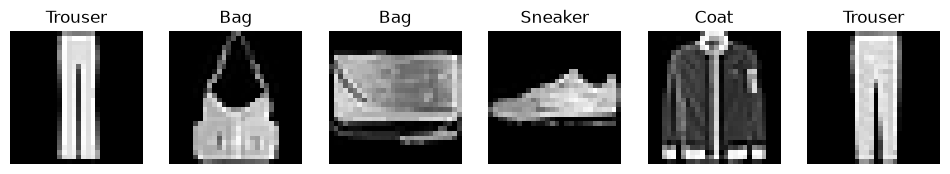

In [2]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, img, label in zip(axes, images[:6], labels[:6]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
plt.show()

In [3]:
images, labels = next(iter(train_loader))
print("images:", images.shape)  # [64, 1, 28, 28]
print("labels:", labels.shape)  # [64]

images: torch.Size([64, 1, 28, 28])
labels: torch.Size([64])


In [4]:
flattened = images.view(images.size(0), -1)
print(flattened.shape)  # [64, 784]

torch.Size([64, 784])


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
images, labels = next(iter(train_loader))
images = images.to(device)
logits = model(images)
print(logits.shape)  # [64, 10]

torch.Size([64, 10])


In [7]:
train_losses = []
val_losses = []

for epoch in range(3):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            running_val += loss.item() * images.size(0)

    val_loss = running_val / len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

Epoch 1: train_loss=0.5914, val_loss=0.4748
Epoch 2: train_loss=0.4335, val_loss=0.4112
Epoch 3: train_loss=0.3909, val_loss=0.4176


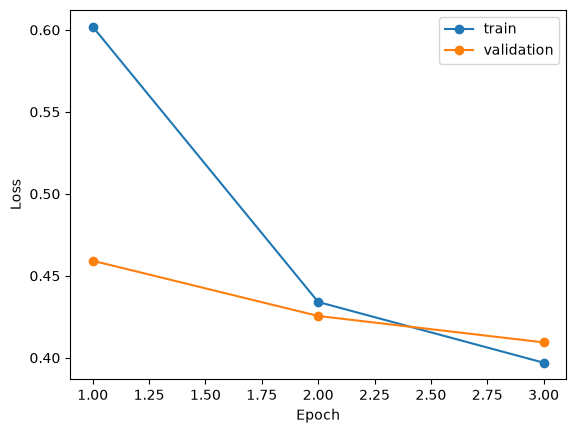

In [9]:
plt.plot(range(1, 4), train_losses, marker="o", label="train")
plt.plot(range(1, 4), val_losses, marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("../reports/loss_curve.png", dpi=200)
plt.show()

In [8]:
model.eval()
correct = []
incorrect = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        for img, label, pred, prob in zip(images, labels, preds, probs):
            if pred.item() == label.item() and len(correct) < 5:
                correct.append((img.cpu(), label.item(), pred.item(), prob.max().item()))
            elif pred.item() != label.item() and len(incorrect) < 5:
                incorrect.append((img.cpu(), label.item(), pred.item(), prob.max().item()))

        if len(correct) >= 5 and len(incorrect) >= 5:
            break

Correct predictions:


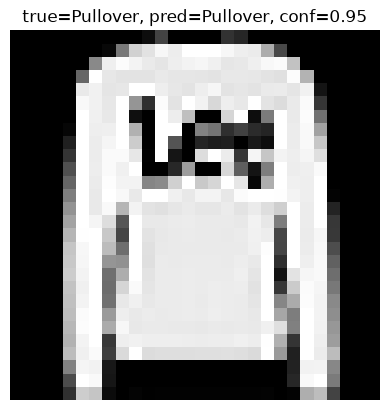

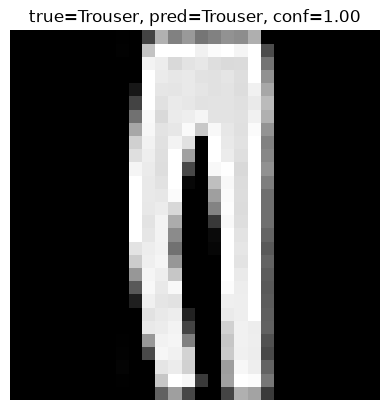

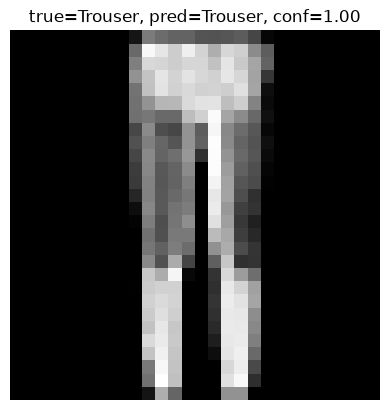

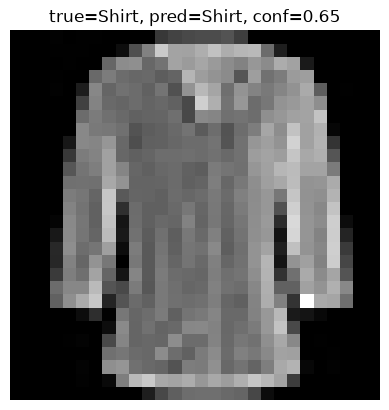

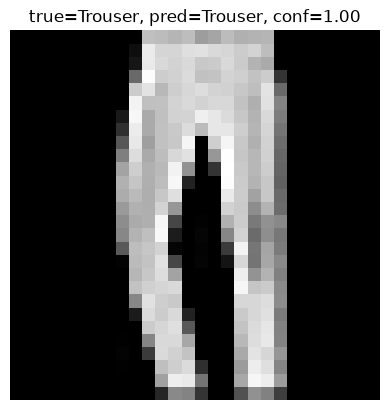

Incorrect predictions:


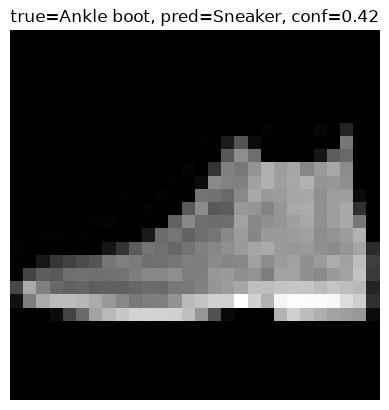

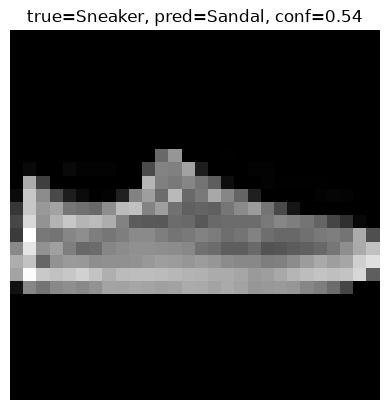

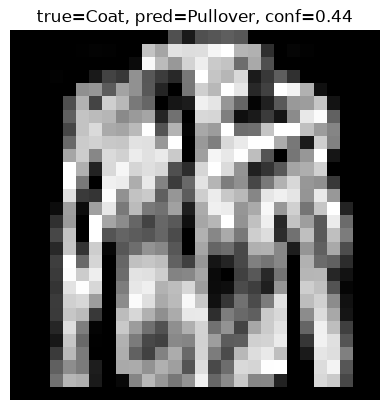

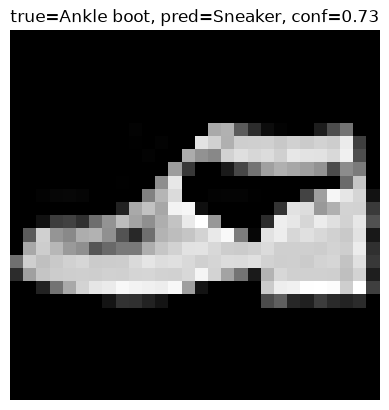

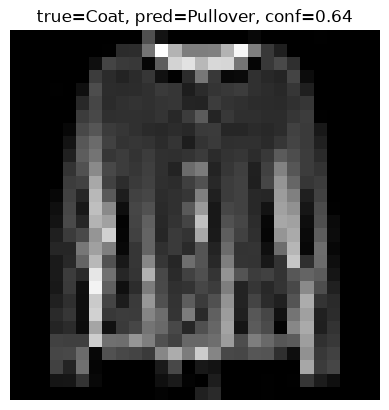

In [9]:
def show_prediction(item):
    img, true, pred, conf = item
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"true={class_names[true]}, pred={class_names[pred]}, conf={conf:.2f}")
    plt.axis("off")
    plt.show()

print("Correct predictions:")
for item in correct:
    show_prediction(item)

print("Incorrect predictions:")
for item in incorrect:
    show_prediction(item)

In [10]:
correct = []
incorrect = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        for img, label, pred, prob in zip(images, labels, preds, probs):
            # Only append if we have less than 5
            if pred.item() == label.item():
                if len(correct) < 5:
                    correct.append((img.cpu(), label.item(), pred.item(), prob.max().item()))
            else:
                if len(incorrect) < 5:
                    incorrect.append((img.cpu(), label.item(), pred.item(), prob.max().item()))

            # Immediately break out of the inner loop once we have exactly 5 of each
            if len(correct) == 5 and len(incorrect) == 5:
                break
        
        # Break out of the outer batch loop
        if len(correct) == 5 and len(incorrect) == 5:
            break

Collected 5 correct and 5 incorrect predictions.

Correct predictions:


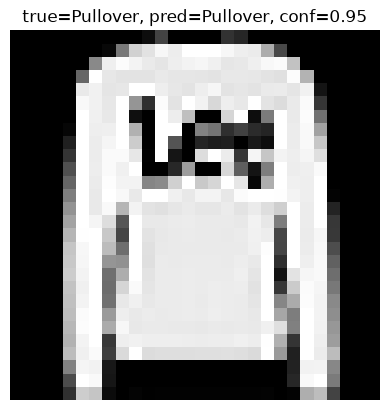

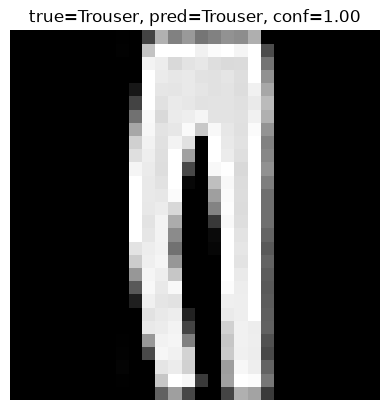

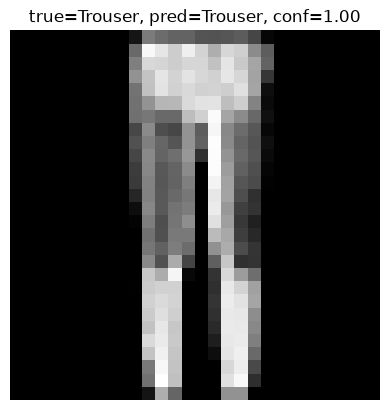

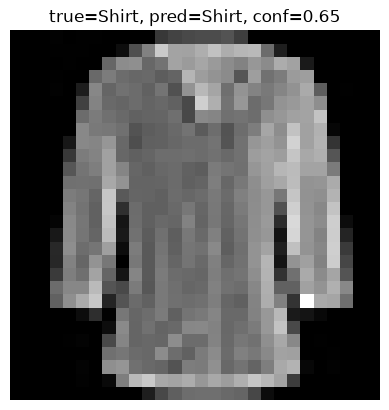

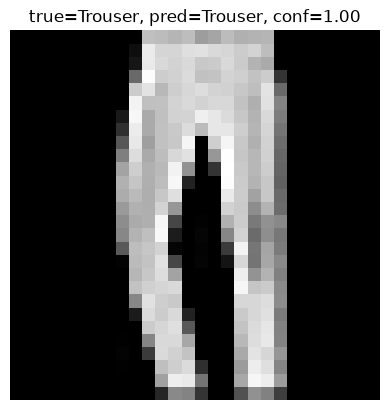

Incorrect predictions:


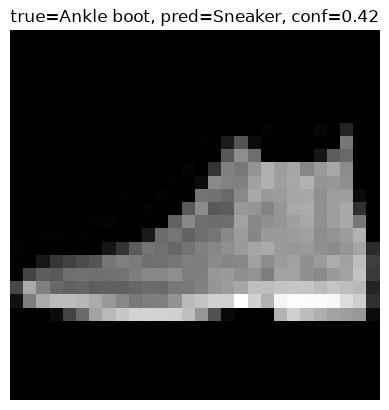

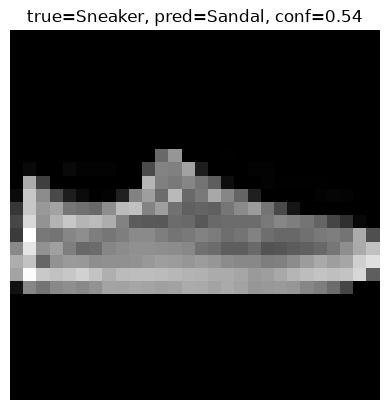

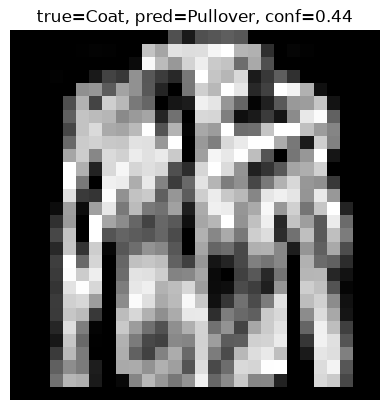

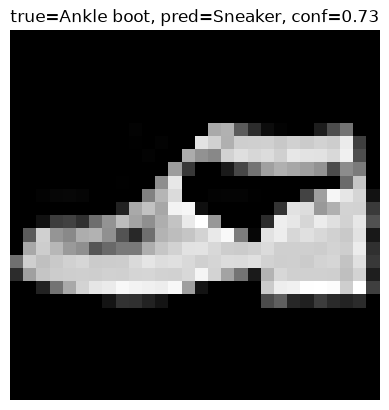

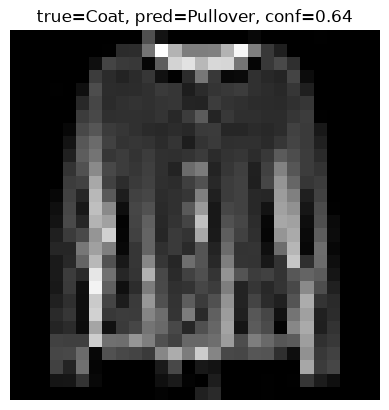

In [11]:
# First, let's check if we actually collected the data
print(f"Collected {len(correct)} correct and {len(incorrect)} incorrect predictions.\n")

def show_prediction(item):
    img, true, pred, conf = item
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"true={class_names[true]}, pred={class_names[pred]}, conf={conf:.2f}")
    plt.axis("off")
    plt.show()

print("Correct predictions:")
for item in correct:
    show_prediction(item)

print("Incorrect predictions:")
for item in incorrect:
    show_prediction(item)

In [12]:
import torch

# 1. Redefine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Reload your class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 3. IMPORTANT: Reload your trained model
# (Make sure you have model defined, or you will get another NameError for 'model')
# If you saved your model weights earlier, load them here:
# model = nn.Sequential(nn.Flatten(), nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 10)).to(device)
# model.load_state_dict(torch.load("../reports/improved_model.pth", map_location=device))
# model.eval()

Using device: cpu


In [13]:
import torch
from torch import nn

# 1. Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Define class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 3. Rebuild the model with 128 hidden units (to match the improved weights)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),  # <-- MUST be 128, not 64
    nn.ReLU(),
    nn.Linear(128, 10)    # <-- MUST be 128, not 64
).to(device)

# 4. Load the saved weights
model.load_state_dict(torch.load("../reports/improved_model.pth", map_location=device))
model.eval()
print("Model loaded successfully!")

Using device: cpu
Model loaded successfully!


In [26]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# 1. The Preprocessing Pipeline
custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Convert to black & white
    transforms.Resize((28, 28)),                 # Shrink to 28x28 pixels
    transforms.ToTensor()                        # Convert to a PyTorch tensor
])

# 2. The Prediction Function
def predict_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert("RGB")
    
    # Preprocess the image
    img_tensor = custom_transform(img)
    
    # Add batch dimension: [1, 28, 28] -> [1, 1, 28, 28]
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs.max().item()
        
    # Display the result
    plt.imshow(img, cmap="gray")
    plt.title(f"Predicted: {class_names[pred_idx]} | Confidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

print("Prediction function ready!")

Prediction function ready!


--- Regular Shoe ---


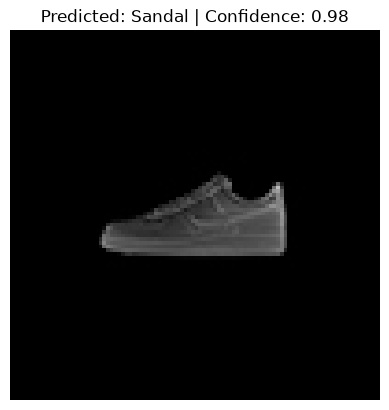


--- Bag ---


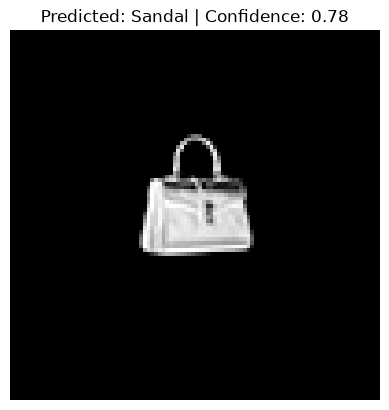


--- Inverted Shoe ---


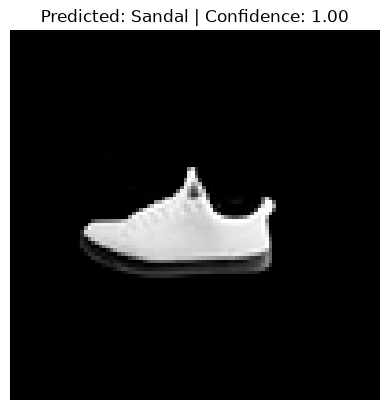

In [28]:
# Test the regular shoe image
print("--- Regular Shoe ---")
predict_custom_image("shoe.jpg")

# Test the bag image
print("\n--- Bag ---")
predict_custom_image("bag.jpg")

# Test your inverted black/white shoe
print("\n--- Inverted Shoe ---")
predict_custom_image("test_shoe.jpg")

### Real-World Inference Failure Analysis

**Observation:** The MLP model confidently predicted "Sandal" for all custom images (bag, regular shoe, inverted shoe), regardless of their actual content.

**Explanation:** 
This failure highlights the limitations of a simple MLP and the importance of domain alignment. Fashion-MNIST consists of white items perfectly centered on a black background. Real-world images have different backgrounds, lighting, angles, and resolutions. 
An MLP flattens the image into a 1D array, destroying all spatial information (edges, shapes, textures). It relies purely on pixel intensity patterns. Because none of the custom images perfectly matched the "white-on-black, centered" distribution of the training data, the model defaulted to "Sandal," which is the class with the broadest, flattest pixel distribution in the dataset. 

**Conclusion:** This proves that for real-world image classification, we need Convolutional Neural Networks (CNNs) which preserve spatial structure, and we must carefully preprocess images to match the training distribution.